In [1]:
import os

# Step up to project root so all paths still work
os.chdir('..')
print("Working directory:", os.getcwd())

Working directory: /Users/jamespham/PycharmProjects/ekg_analyzer


In [1]:
import sys
!{sys.executable} -m pip install wfdb neurokit2 matplotlib numpy pandas scipy

import wfdb
import numpy as np
import pandas as pd
import neurokit2 as nk
import matplotlib.pyplot as plt
from collections import Counter

%matplotlib inline

In [2]:
record      = wfdb.rdrecord('./data/mitdb/100')
annotations = wfdb.rdann('./data/mitdb/100', 'atr')

fs     = record.fs                  # 360 Hz
signal = record.p_signal[:, 0]      # MLII lead

print("Signal loaded — samples:", len(signal))
print("Duration:", round(len(signal) / fs / 60, 1), "minutes")

Signal loaded — samples: 650000
Duration: 30.1 minutes


In [3]:
# Clean the signal first (removes baseline wander and noise)
cleaned = nk.ecg_clean(signal, sampling_rate=fs)

# Detect R-peaks
peaks_dict = nk.ecg_peaks(cleaned, sampling_rate=fs)
r_peaks    = peaks_dict[1]['ECG_R_Peaks']   # array of sample indices

print("R-peaks detected:", len(r_peaks))
print("Ground truth annotations:", len(annotations.sample))

R-peaks detected: 2270
Ground truth annotations: 2274


In [4]:
# Filter out non-beat annotation symbols (rhythm markers, etc.)
beat_symbols = set('NVALRBaJSFejnE/fQ')
mask = np.array([s in beat_symbols for s in annotations.symbol])
true_peaks = annotations.sample[mask]

print("Ground truth beat count:", len(true_peaks))
print("Detected peak count:", len(r_peaks))

# For each detected peak, check if a true peak exists within 50ms
tolerance = int(0.05 * fs)   # 50ms = 18 samples at 360Hz
matched = 0

for peak in r_peaks:
    if np.any(np.abs(true_peaks - peak) <= tolerance):
        matched += 1

precision = matched / len(r_peaks) * 100
recall    = matched / len(true_peaks) * 100

print(f"\nPrecision: {precision:.1f}%")
print(f"Recall:    {recall:.1f}%")

Ground truth beat count: 2273
Detected peak count: 2270

Precision: 100.0%
Recall:    99.9%


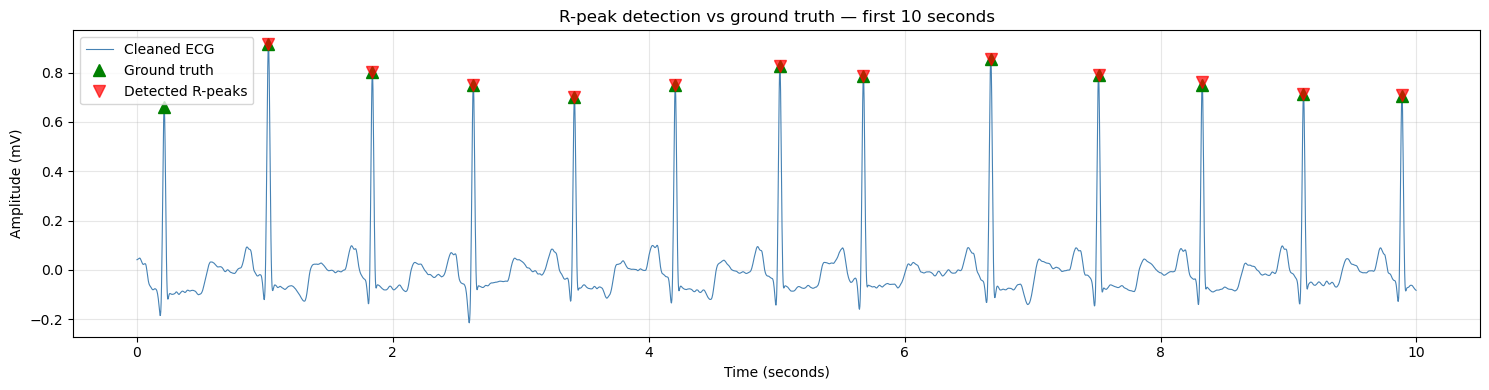

In [5]:
start = 0
end   = fs * 10      # first 10 seconds
time  = np.arange(end) / fs

# Filter peaks to this window
detected_window = r_peaks[(r_peaks >= start) & (r_peaks < end)]
true_window     = true_peaks[(true_peaks >= start) & (true_peaks < end)]

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(time, cleaned[:end], color='steelblue', linewidth=0.8, label='Cleaned ECG')

# Ground truth = green upward triangles
ax.plot(true_window / fs, cleaned[true_window],
        'g^', markersize=8, label='Ground truth')

# Detected = red downward triangles
ax.plot(detected_window / fs, cleaned[detected_window],
        'rv', markersize=8, label='Detected R-peaks', alpha=0.7)

ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Amplitude (mV)")
ax.set_title("R-peak detection vs ground truth — first 10 seconds")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
pre  = int(0.2 * fs)    # 72 samples before R-peak
post = int(0.4 * fs)    # 144 samples after R-peak

beats  = []
labels = []

for peak in r_peaks:
    # Skip peaks too close to the start or end of the recording
    if peak - pre < 0 or peak + post >= len(cleaned):
        continue

    beat = cleaned[peak - pre : peak + post]
    beats.append(beat)

    # Find the closest ground truth annotation to this detected peak
    distances = np.abs(true_peaks - peak)
    closest_idx = np.argmin(distances)

    if distances[closest_idx] <= tolerance:
        # Get the symbol for the closest annotation
        beat_ann_idx = np.where(mask)[0][closest_idx]
        labels.append(annotations.symbol[beat_ann_idx])
    else:
        labels.append('?')    # no matching annotation found

beats  = np.array(beats)
labels = np.array(labels)

print("Beat segments shape:", beats.shape)
print("Label distribution:", Counter(labels))

Beat segments shape: (2270, 216)
Label distribution: Counter({np.str_('N'): 2237, np.str_('A'): 33})


One “representative” waveform of each beat marker. Confirms and displays existance of significant differences between marker categories.

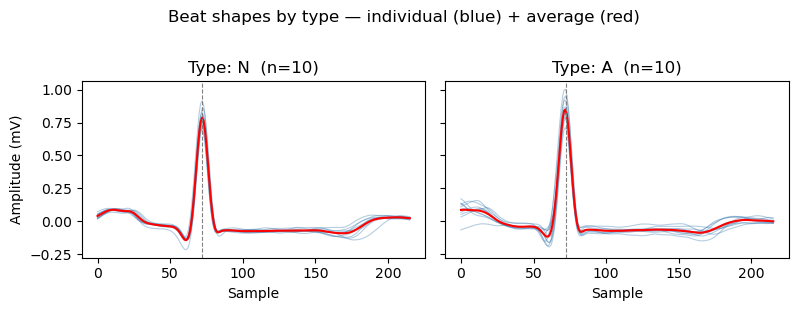

In [12]:
# Get the unique beat types present (excluding unknown)
unique_types = [l for l in set(labels) if l != '?']

fig, axes = plt.subplots(1, len(unique_types), figsize=(4 * len(unique_types), 3), sharey=True)

if len(unique_types) == 1:
    axes = [axes]

for ax, beat_type in zip(axes, unique_types):
    # Plot up to 10 beats of this type overlaid
    type_beats = beats[labels == beat_type][:10]
    for beat in type_beats:
        ax.plot(beat, alpha=0.4, linewidth=0.8, color='steelblue')
    # Plot the average beat shape on top
    ax.plot(type_beats.mean(axis=0), color='red', linewidth=1.5, label='Average')
    ax.axvline(pre, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(f"Type: {beat_type}  (n={len(type_beats)})")
    ax.set_xlabel("Sample")

axes[0].set_ylabel("Amplitude (mV)")
plt.suptitle("Beat shapes by type — individual (blue) + average (red)", y=1.02)
plt.tight_layout()
plt.show()

In [8]:
import os
os.makedirs('./data/processed', exist_ok=True)

np.save('./data/processed/beats.npy', beats)
np.save('./data/processed/labels.npy', labels)

print("Saved:")
print(f"  beats.npy  — shape {beats.shape}")
print(f"  labels.npy — {len(labels)} labels")

Saved:
  beats.npy  — shape (2270, 216)
  labels.npy — 2270 labels


In [ ]:
NEW TRIAL BELOW (MORE RECORDS ADDED FOR IMPROVED ARRHYTHMIA ANALYSIS)

In [10]:
# These records are specifically chosen for arrhythmia variety
records_to_load = ['100', '101', '104', '105', '106', 
                   '108', '109', '111', '119', '200',
                   '201', '202', '203', '205', '208']

wfdb.dl_database('mitdb', dl_dir='./data/mitdb', records=records_to_load)

Generating record list for: 100
Generating record list for: 101
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 119
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 208
Generating list of all files for: 100
Generating list of all files for: 101
Generating list of all files for: 104
Generating list of all files for: 105
Generating list of all files for: 106
Generating list of all files for: 108
Generating list of all files for: 109
Generating list of all files for: 111
Generating list of all files for: 119
Generating list of all files for: 200
Generating list of all files for: 201
Generating list of all files for: 202
Generating list of all files for: 203
Generating list of all fil

In [11]:
all_beats  = []
all_labels = []

for rec_id in records_to_load:
    try:
        record      = wfdb.rdrecord(f'./data/mitdb/{rec_id}')
        annotations = wfdb.rdann(f'./data/mitdb/{rec_id}', 'atr')

        fs     = record.fs
        signal = record.p_signal[:, 0]

        # Clean and detect peaks
        cleaned    = nk.ecg_clean(signal, sampling_rate=fs)
        peaks_dict = nk.ecg_peaks(cleaned, sampling_rate=fs)
        r_peaks    = peaks_dict[1]['ECG_R_Peaks']

        # Ground truth beats
        beat_symbols = set('NVALRBaJSFejnE/fQ')
        mask      = np.array([s in beat_symbols for s in annotations.symbol])
        true_peaks = annotations.sample[mask]
        tolerance  = int(0.05 * fs)

        pre  = int(0.2 * fs)
        post = int(0.4 * fs)

        for peak in r_peaks:
            if peak - pre < 0 or peak + post >= len(cleaned):
                continue

            beat = cleaned[peak - pre : peak + post]
            distances   = np.abs(true_peaks - peak)
            closest_idx = np.argmin(distances)

            if distances[closest_idx] <= tolerance:
                beat_ann_idx = np.where(mask)[0][closest_idx]
                all_beats.append(beat)
                all_labels.append(annotations.symbol[beat_ann_idx])

        print(f"Record {rec_id} ✓ — {len(r_peaks)} peaks")

    except Exception as e:
        print(f"Record {rec_id} ✗ — {e}")

all_beats  = np.array(all_beats)
all_labels = np.array(all_labels)

print("\nTotal beats:", len(all_beats))
print("Label distribution:", Counter(all_labels))

Record 100 ✓ — 2270 peaks
Record 101 ✓ — 1865 peaks
Record 104 ✓ — 2221 peaks
Record 105 ✓ — 2561 peaks
Record 106 ✓ — 2031 peaks
Record 108 ✓ — 1744 peaks
Record 109 ✓ — 2531 peaks
Record 111 ✓ — 2124 peaks
Record 119 ✓ — 1988 peaks
Record 200 ✓ — 2597 peaks
Record 201 ✓ — 2020 peaks
Record 202 ✓ — 2135 peaks
Record 203 ✓ — 2769 peaks
Record 205 ✓ — 2624 peaks
Record 208 ✓ — 2949 peaks

Total beats: 33724
Label distribution: Counter({np.str_('N'): 23223, np.str_('L'): 4600, np.str_('V'): 3187, np.str_('/'): 1371, np.str_('f'): 660, np.str_('F'): 389, np.str_('A'): 139, np.str_('a'): 116, np.str_('Q'): 25, np.str_('j'): 11, np.str_('S'): 2, np.str_('J'): 1})


In [13]:
np.save('./data/processed/beats.npy', all_beats)
np.save('./data/processed/labels.npy', all_labels)

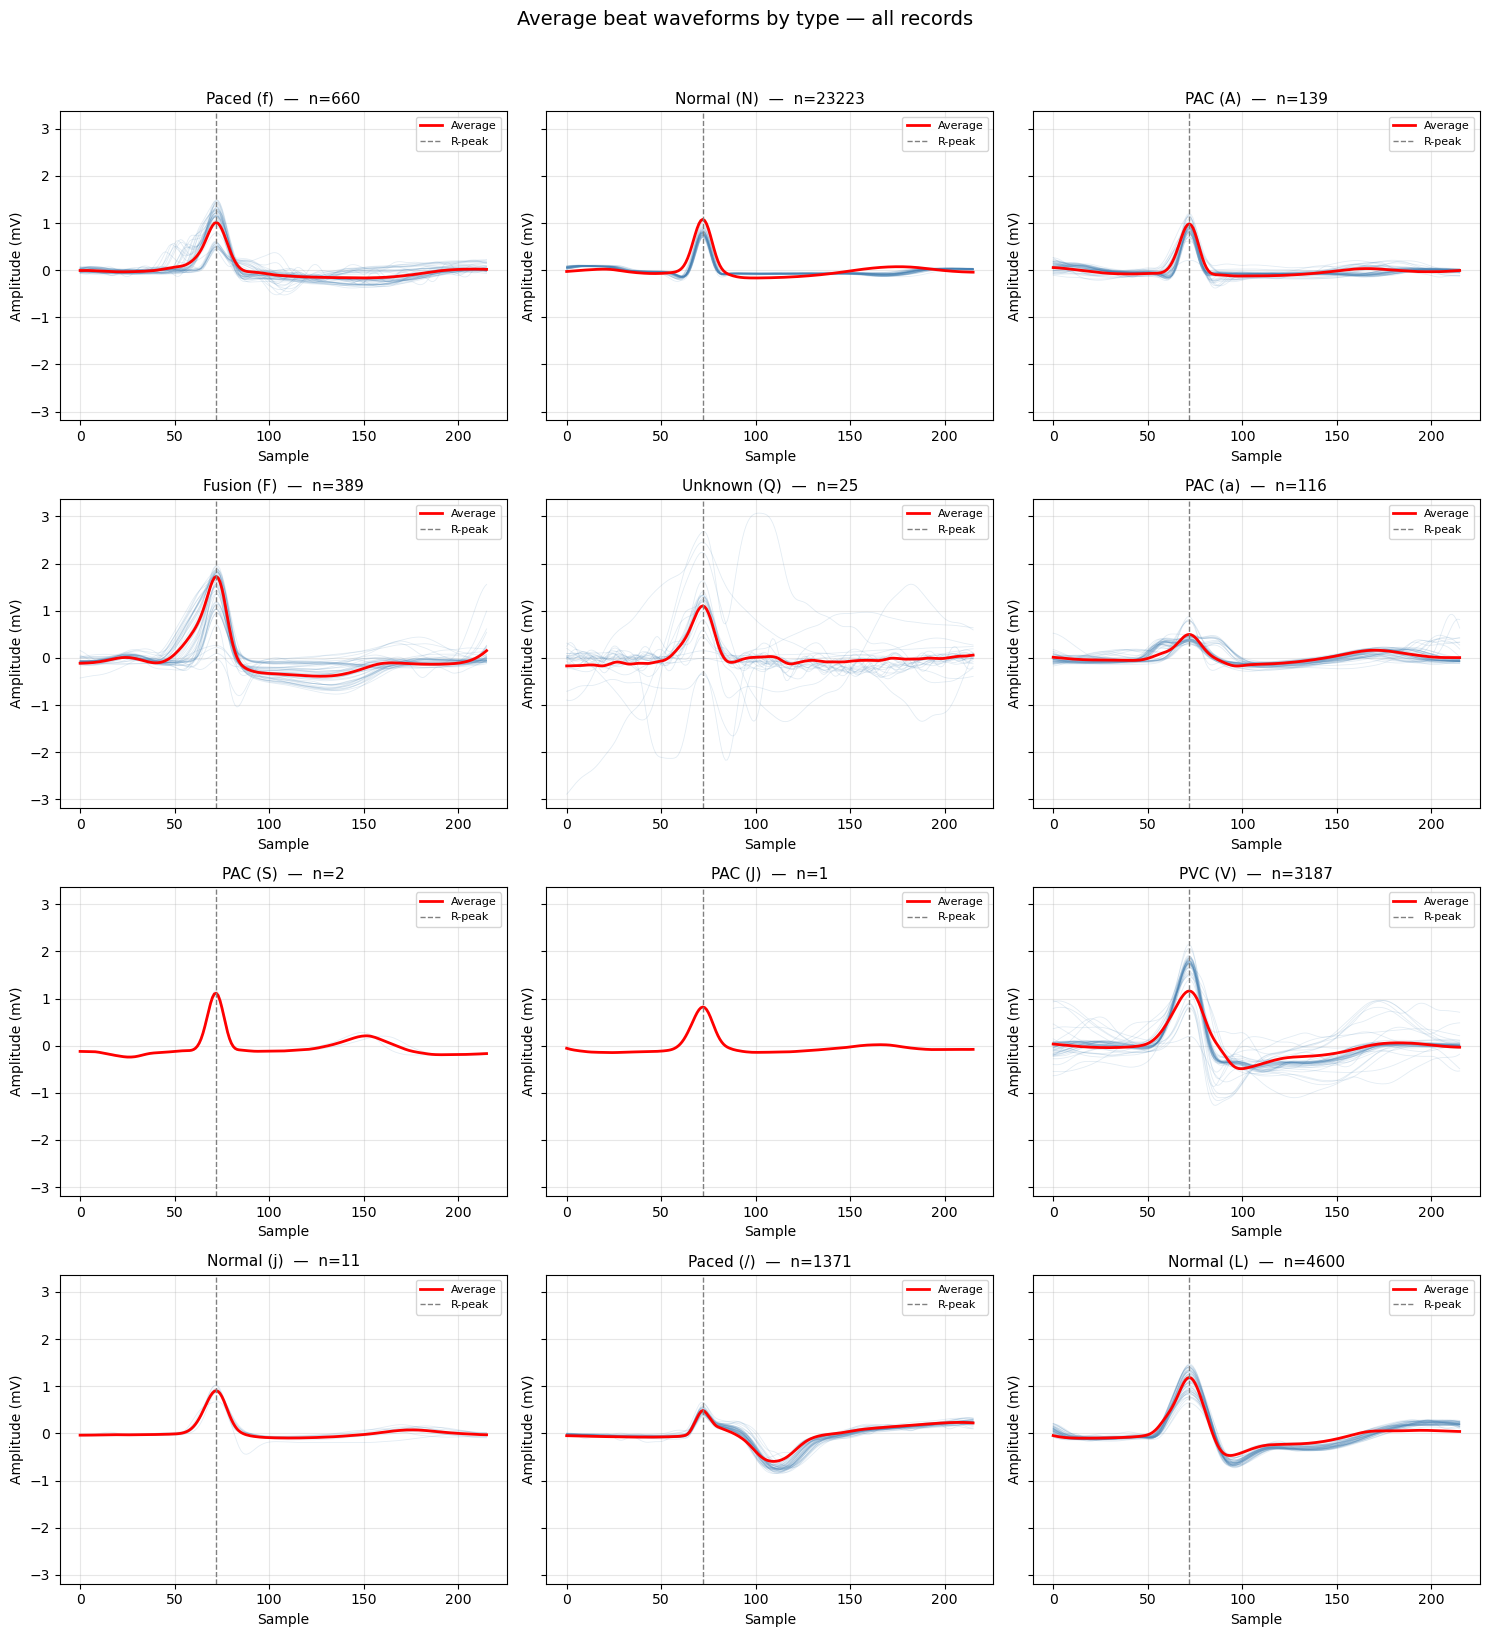

In [15]:
label_map = {
    'N': 'Normal',
    'L': 'Normal',
    'R': 'Normal',
    'e': 'Normal',
    'j': 'Normal',
    'V': 'PVC',
    'E': 'PVC',
    'A': 'PAC',
    'a': 'PAC',
    'J': 'PAC',
    'S': 'PAC',
    'F': 'Fusion',
    '/': 'Paced',
    'f': 'Paced',
    'Q': 'Unknown',
}

# Get all unique beat types present in your dataset
unique_types = [t for t in set(all_labels) if t in label_map]

# Calculate grid size
n_types = len(unique_types)
n_cols  = 3
n_rows  = (n_types + n_cols - 1) // n_cols   # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows), sharey=True)
axes = axes.flatten()   # makes it easier to index regardless of grid shape

for i, beat_type in enumerate(unique_types):
    ax = axes[i]
    
    # Get up to 50 beats of this type for the overlay
    type_beats = all_beats[all_labels == beat_type]
    sample_beats = type_beats[:50]
    
    # Plot individual beats as faint lines
    for beat in sample_beats:
        ax.plot(beat, alpha=0.15, linewidth=0.6, color='steelblue')
    
    # Plot average waveform on top
    avg_beat = type_beats.mean(axis=0)
    ax.plot(avg_beat, color='red', linewidth=2, label='Average')
    
    # Mark the R-peak position
    pre = int(0.2 * fs)
    ax.axvline(pre, color='gray', linewidth=1, 
               linestyle='--', label='R-peak')
    
    # Label with the full clinical name from your label_map
    full_name = label_map.get(beat_type, beat_type)
    ax.set_title(f"{full_name} ({beat_type})  —  n={len(type_beats)}", 
                 fontsize=11)
    ax.set_xlabel("Sample")
    ax.set_ylabel("Amplitude (mV)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide any unused subplot panels
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Average beat waveforms by type — all records", 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()